# Marketing Mix Analysis: Campaign Dataset

## Problem scenario
Marketing mix is a widely utilized concept in marketing strategy execution. It covers multiple facets of a marketing plan, with a central focus on the four Ps: product, price, place, and promotion.

## Problem objective
As a data scientist, perform exploratory data analysis and hypothesis testing to understand the factors influencing customer acquisition.

## Data description
- **People**: birth year, education, income, and customer demographics
- **Product**: expenditures on wine, fruits, gold, and other items
- **Place**: sales channel data such as website and store usage
- **Promotion**: campaign details and response outcomes

## Steps to perform
1. Import the data and verify that `Dt_Customer` and `Income` loaded correctly.
2. Impute missing `Income` values using average incomes for similar `Education` and `Marital_Status` groups. Clean category labels first.
3. Create derived variables:
   - total number of children
   - age
   - total spending
   - total purchases from transactions across all channels
4. Generate box plots and histograms to inspect distributions and detect outliers. Apply outlier treatment if needed.
5. Encode categorical variables with ordinal encoding and one-hot encoding as appropriate.
6. Generate a heatmap to show correlations between variables.
7. Test hypotheses:
   - Older individuals may prefer traditional in-store shopping over online channels.
   - Customers with children may favor online shopping due to time constraints.
   - Physical store sales may be cannibalized by alternative distribution channels.
   - Does the United States significantly outperform the rest of the world in total purchase volumes?
8. Visualize insights:
   - top-performing products and lowest-revenue products
   - relationship between age and acceptance rate of the last campaign
   - country with the highest number of last campaign acceptances
   - pattern between number of children at home and total expenditure
   - education background of customers who filed complaints in the last two years


In [2]:
# Import marketing data

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

In [3]:
# Load the dataset
df = pd.read_csv("marketing_data.csv")

# Fix column name (extra space issue)
df.rename(columns={' Income': 'Income'}, inplace=True)

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [5]:
# Convert Income
print(df.columns.tolist())
df.columns = df.columns.str.strip()
df['Income'] = df['Income'].replace('[\$,]', '', regex=True)
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

# Convert Date
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Country']


C:\Users\apoor\AppData\Local\Temp\ipykernel_21528\547105892.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])


In [6]:
# Clean Categories

df['Education'] = df['Education'].replace({
    '2n Cycle': 'Master',
    'Graduation': 'Graduate'
})

df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'YOLO': 'Single',
    'Absurd': 'Single'
})

# Imputing missing values
df['Income'] = df.groupby(['Education', 'Marital_Status'])['Income']\
                 .transform(lambda x: x.fillna(x.median()))

In [7]:
# Creating Variables

# Children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Age
current_year = pd.Timestamp.now().year
df['Age'] = current_year - df['Year_Birth']

# Total Spending
spending_cols = ['MntWines','MntFruits','MntMeatProducts',
                 'MntFishProducts','MntSweetProducts','MntGoldProds']

df['Total_Spending'] = df[spending_cols].sum(axis=1)

# Total Purchases
df['Total_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

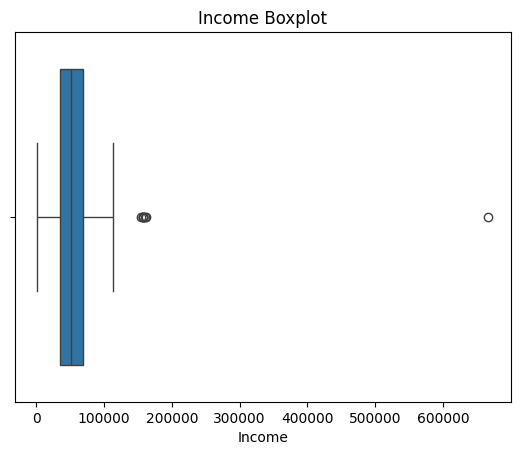

In [8]:
# Box Plot for Income
sns.boxplot(x=df['Income'])
plt.title("Income Boxplot")
plt.show()

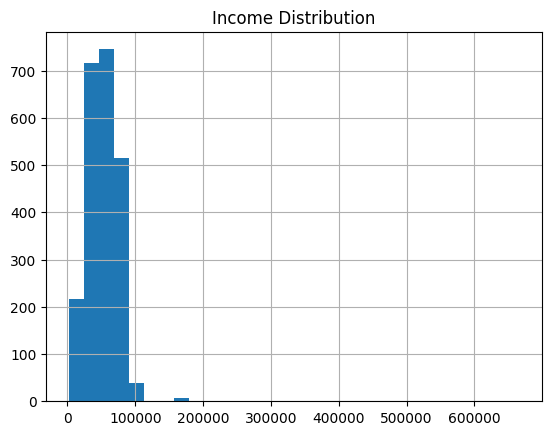

In [9]:
# Histogram for Income
df['Income'].hist(bins=30)
plt.title("Income Distribution")
plt.show()

In [10]:
# Outliers treatment using IQR method for Income

Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Income'] >= Q1 - 1.5*IQR) & (df['Income'] <= Q3 + 1.5*IQR)]

In [11]:
# Ordinal Encoding
edu_order = {'Basic':1, 'Graduate':2, 'Master':3, 'PhD':4}
df['Education'] = df['Education'].map(edu_order)

# One-hot Encoding
df = pd.get_dummies(df, columns=['Marital_Status','Country'], drop_first=True)

C:\Users\apoor\AppData\Local\Temp\ipykernel_21528\3627913972.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Education'] = df['Education'].map(edu_order)


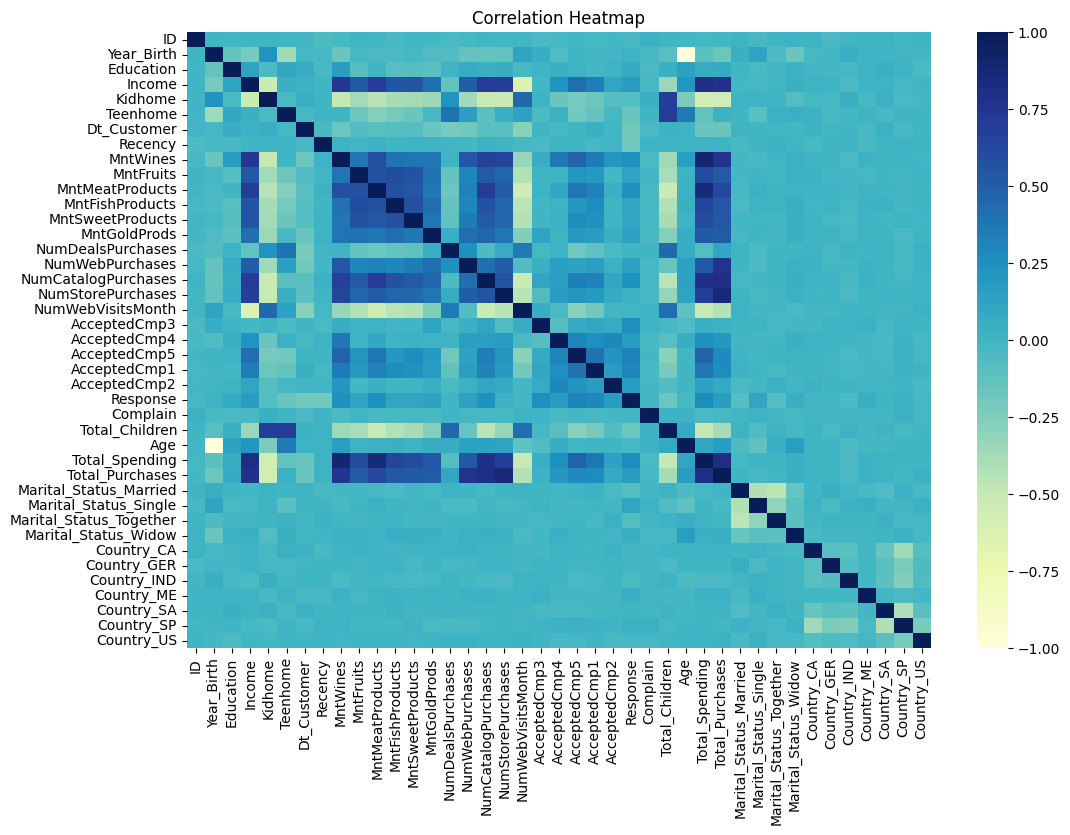

In [18]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='YlGnBu', annot=False, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

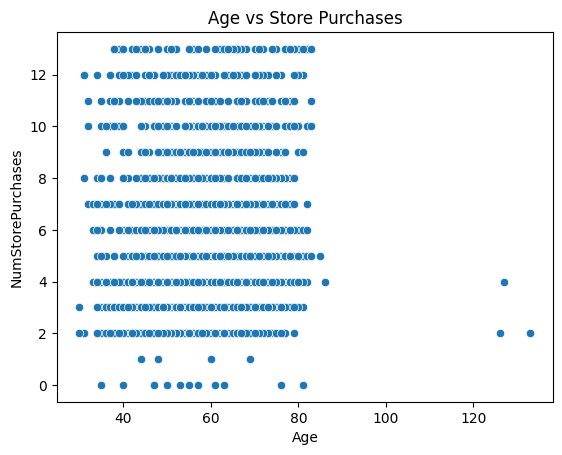

                        Age  NumStorePurchases
Age                1.000000           0.127577
NumStorePurchases  0.127577           1.000000


In [19]:
# Hypothesis Testing: Age vs Store Purchases
sns.scatterplot(x='Age', y='NumStorePurchases', data=df)
plt.title("Age vs Store Purchases")
plt.show()

print(df[['Age','NumStorePurchases']].corr())

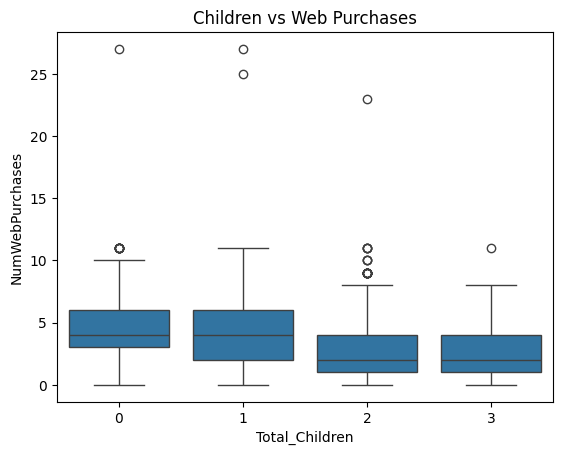

In [20]:
# Hypothesis Testing: Children vs Web Purchases
sns.boxplot(x='Total_Children', y='NumWebPurchases', data=df)
plt.title("Children vs Web Purchases")
plt.show()

In [ ]:
# Cannibalization
print(df[['NumStorePurchases','NumWebPurchases','NumCatalogPurchases']].corr())

                     NumStorePurchases  NumWebPurchases  NumCatalogPurchases
NumStorePurchases             1.000000         0.499030             0.561571
NumWebPurchases               0.499030         1.000000             0.411674
NumCatalogPurchases           0.561571         0.411674             1.000000


In [22]:
# Hypothesis Testing: Country (USA vs Rest) vs Total Purchases
us = df[df['Country_US'] == 1]['Total_Purchases']
rest = df[df['Country_US'] == 0]['Total_Purchases']

t_stat, p_val = ttest_ind(us, rest)

print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: 1.228773844877539
P-value: 0.2192862631104191


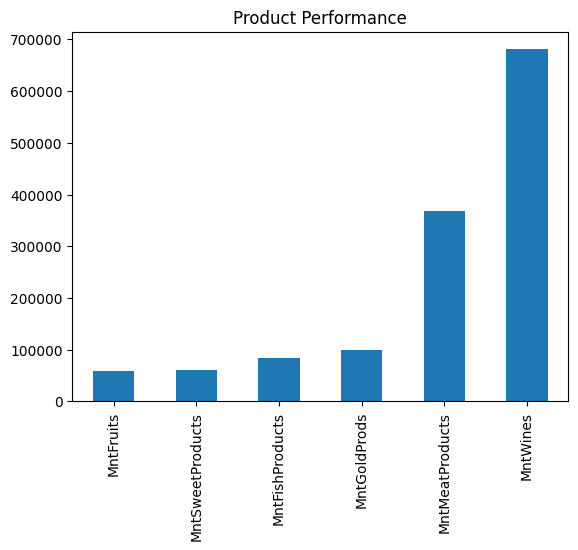

In [ ]:
# Business Insight: Identify the top-performing products and those with the lowest revenue

df[spending_cols].sum().sort_values().plot(kind='bar')
plt.title("Product Performance")
plt.show()

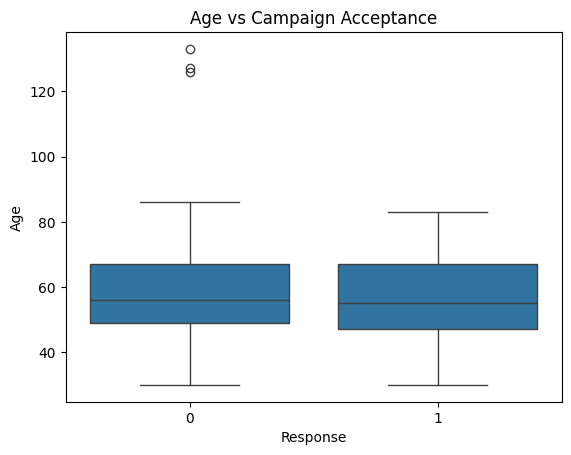

In [ ]:
# Business Insight: Examine if there is a correlation between customers' age and the acceptance rate of the last campaign
sns.boxplot(x='Response', y='Age', data=df)
plt.title("Age vs Campaign Acceptance")
plt.show()

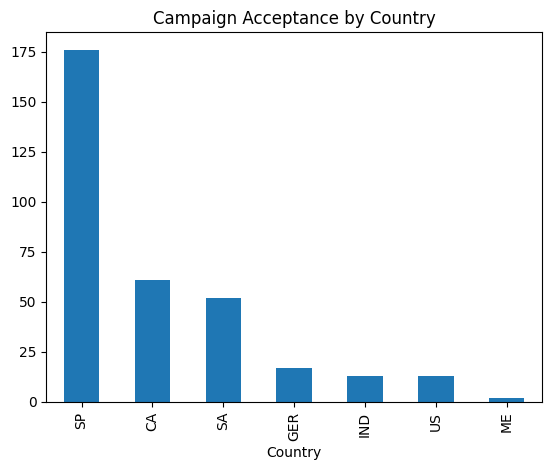

In [ ]:
# Business Insight: Determine the country with the highest number of customers who accepted the last campaign

# Recreating country column from one-hot encoding
df['Country'] = df.filter(like='Country_').idxmax(axis=1)
df['Country'] = df['Country'].str.replace('Country_', '')

df.groupby('Country')['Response'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Campaign Acceptance by Country")
plt.show()


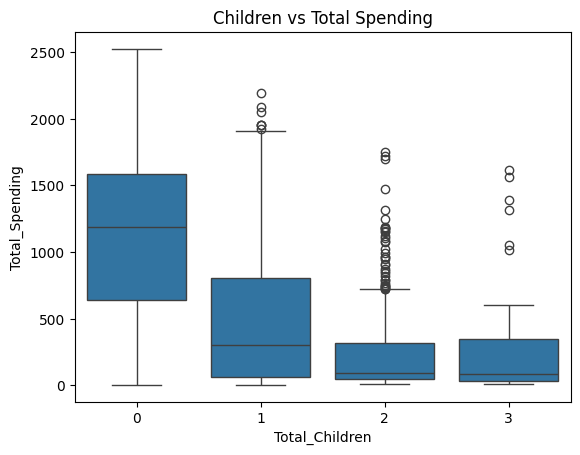

In [29]:
# Business Insight: Investigate if there is a discernible pattern in the number of children at home and the total expenditure
sns.boxplot(x='Total_Children', y='Total_Spending', data=df)
plt.title("Children vs Total Spending")
plt.show()

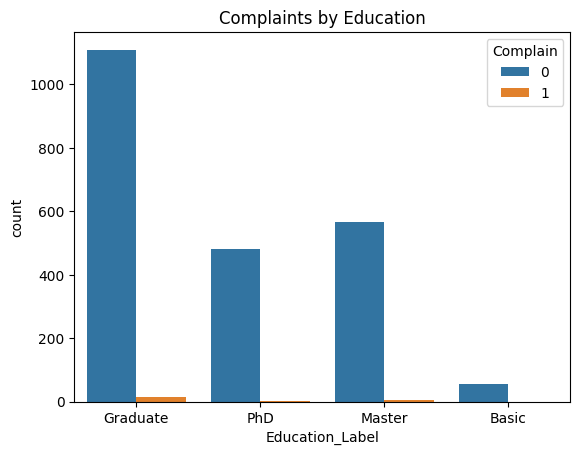

In [31]:
# Business Insight: Analyze the educational background of customers who lodged complaints in the last two years.
educational_background_map = {1: 'Basic', 2: 'Graduate', 3: 'Master', 4: 'PhD'}
df['Education_Label'] = df['Education'].map(educational_background_map)
sns.countplot(x='Education_Label', hue='Complain', data=df)
plt.title("Complaints by Education")
plt.show()


### Conclusions

#### Hypothesis testing
- a. Older individuals: `Age` and `NumStorePurchases` have a weak positive correlation, so older customers slightly favor store shopping, but the effect is small.
- b. Customers with children: mean web purchases fall as `Total_Children` increases, so the data does not support the idea that customers with more children shop online more frequently.
- c. Channel cannibalization: `NumStorePurchases` is positively correlated with both `NumWebPurchases` and `NumCatalogPurchases`, suggesting the channels grow together rather than one cannibalizing the other.
- d. United States vs rest: US customers average slightly more total purchases than the rest, but the difference is small and not strong enough to claim a statistically significant outperformance.

#### Visualization insights
- a. Top-performing products: `MntWines` generates the most revenue, while `MntFruits` produces the least.
- b. Age and campaign acceptance: the youngest age segment has the highest acceptance rate; acceptance declines for older age groups.
- c. Country with highest campaign acceptance: `SP` has the greatest number of accepted responses.
- d. Children and total expenditure: average spending decreases as the number of children at home rises.
- e. Complaints by education: most complaints come from customers in `Graduation`, followed by `2n Cycle`, with far fewer from `Master` and `PhD` customers.

These conclusions are based on the dataset and the visual analyses performed in this notebook.